In [3]:
import pandas as pd
#1.Read our cleaned data
df=pd.read_csv('sales_data_clean.csv')
#2.Check the first 5 rows of the data to confirm it has been loaded
df.head()

,Order_ID,Customer_ID,Date,Age,Gender,City,Product_Category,Unit_Price,Quantity,Discount_Amount,Total_Amount,Payment_Method,Device_Type,Session_Duration_Minutes,Pages_Viewed,Is_Returning_Customer,Delivery_Time_Days,Customer_Rating
0,ORD_001337,CUST_01337,2023-01-01,27,Female,Bursa,Toys,54.28,1,0.00,54.28,Debit Card,Mobile,4,14,True,8,5
1,ORD_004885,CUST_04885,2023-01-01,42,Male,Konya,Toys,244.90,1,0.00,244.90,Credit Card,Mobile,11,3,True,3,3
2,ORD_004507,CUST_04507,2023-01-01,43,Female,Ankara,Food,48.15,5,0.00,240.75,Credit Card,Mobile,7,8,True,5,2
3,ORD_000645,CUST_00645,2023-01-01,32,Male,Istanbul,Electronics,804.06,1,229.28,574.78,Credit Card,Mobile,8,10,False,1,4
4,ORD_000690,CUST_00690,2023-01-01,40,Female,Istanbul,Sports,755.61,5,0.00,3778.05,Cash on Delivery,Desktop,21,10,True,7,4


Part1 Basic Logistics Analysis





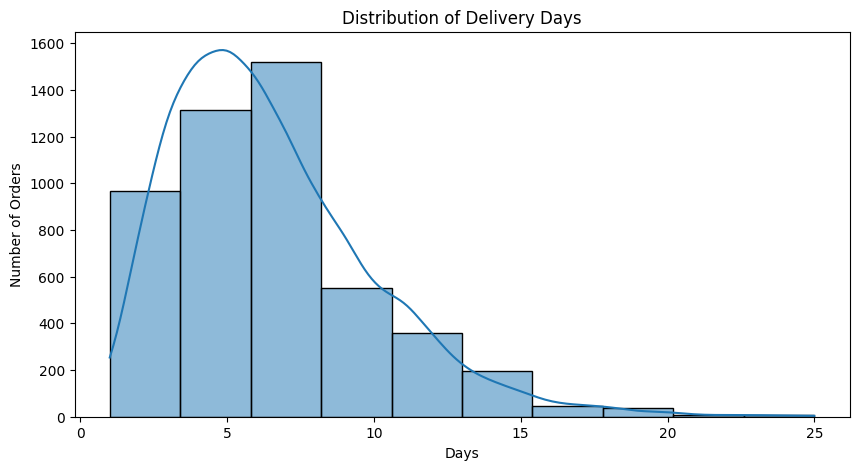

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

#Set the figure size
plt.figure(figsize=(10,5))

#Plot the distribution of delivery days
#bins=10 groups the days, kde=True adds the smooth trend line
sns.histplot(df['Delivery_Time_Days'],bins=10,kde=True)
plt.title('Distribution of Delivery Days')
plt.xlabel('Days')
plt.ylabel('Number of Orders')
plt.show()


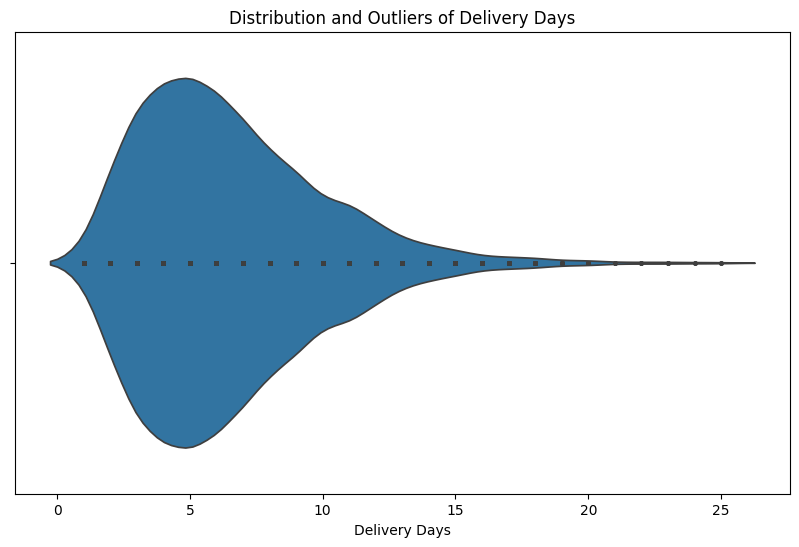

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.violinplot(x=df['Delivery_Time_Days'],inner='point')
plt.title('Distribution and Outliers of Delivery Days')
plt.xlabel('Delivery Days')
plt.ylabel('')
plt.show()


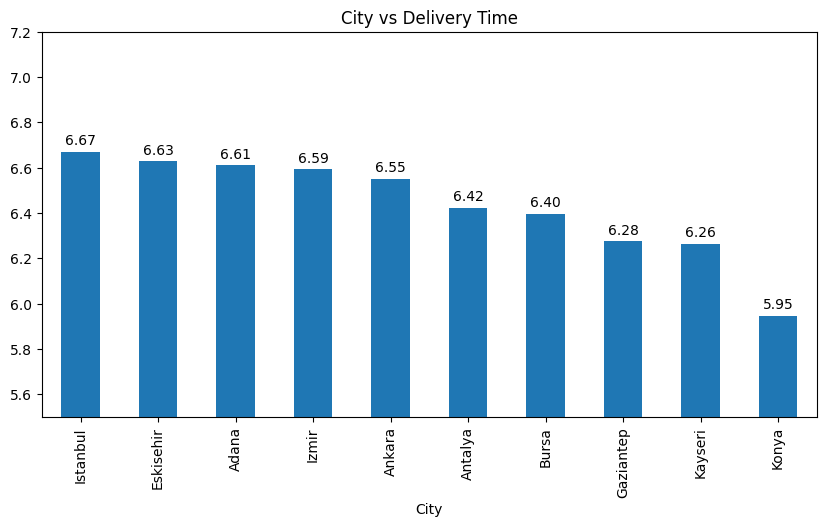

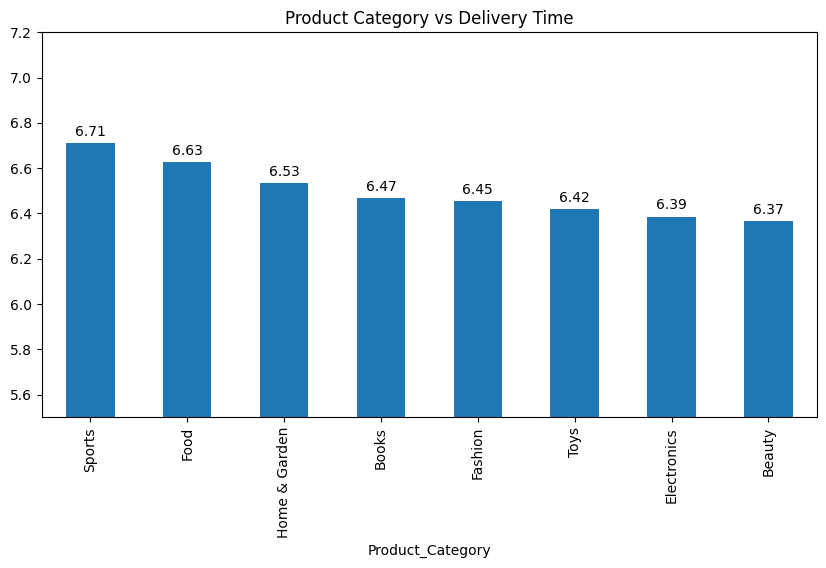

In [6]:
from numpy.random.mtrand import f
import matplotlib.pyplot as plt
#1.Plot the average delivery time for each city
axl=df.groupby('City')['Delivery_Time_Days'].mean().sort_values(ascending=False).plot(kind='bar',figsize=(10,5),title='City vs Delivery Time')
plt.ylim(5.5,7.2)
plt.bar_label(axl.containers[0],fmt='%.2f',padding=3)
plt.show()
#2.Plot the average delivery time for each product category
ax2=df.groupby('Product_Category')['Delivery_Time_Days'].mean().sort_values(ascending=False).plot(kind='bar',figsize=(10,5),title='Product Category vs Delivery Time')
plt.ylim(5.5,7.2)
plt.bar_label(ax2.containers[0],fmt='%.2f',padding=3)
plt.show()

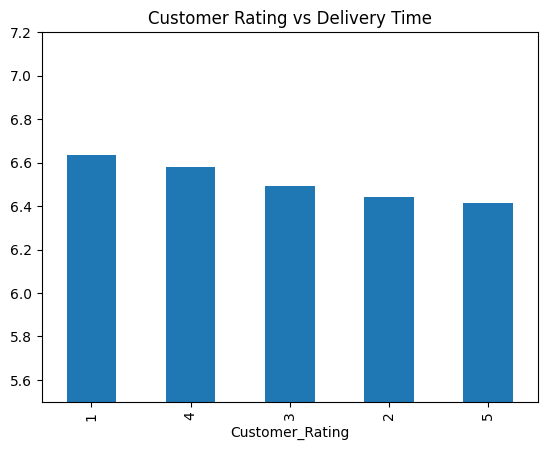

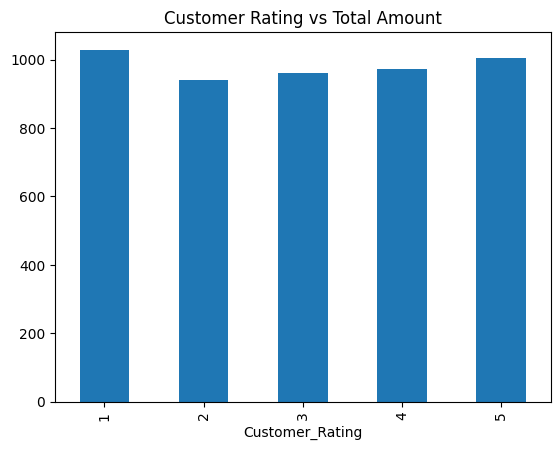

In [ ]:
#Relationship between delivery time and customer rating
df.groupby('Customer_Rating')['Delivery_Time_Days'].mean().sort_values(ascending=False).plot(kind='bar',title='Customer Rating vs Delivery Time')
plt.ylim(5.5,7.2)
plt.show()
#Difference in average total amount between low and high-rated orders
df.groupby('Customer_Rating')['Total_Amount'].mean().plot(kind='bar',title='Customer Rating vs Total Amount')
plt.show()

Part 2:Predict Delivery Time (Random Forest)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
import pandas as pd
#Select features (City,Category,Quantity) and target (Delivery Time)
#Using get_dummies to convert text to numbers
X=pd.get_dummies(df[['City','Product_Category','Quantity']])
y=df['Delivery_Time_Days']

#Split data:80% for trainning,20% for testing
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

#Build and train the Random Forest model
rf=RandomForestRegressor(n_estimators=100,random_state=42)
rf.fit(X_train,y_train)

#Check the model Score
score=rf.score(X_test,y_test)
print(f'Model Score:{score}')

Model Score:-0.10626805896854274


Part3:Key Factors Affecting Delivery Extracting feature importance from the model to find out what impacts delivery time the most

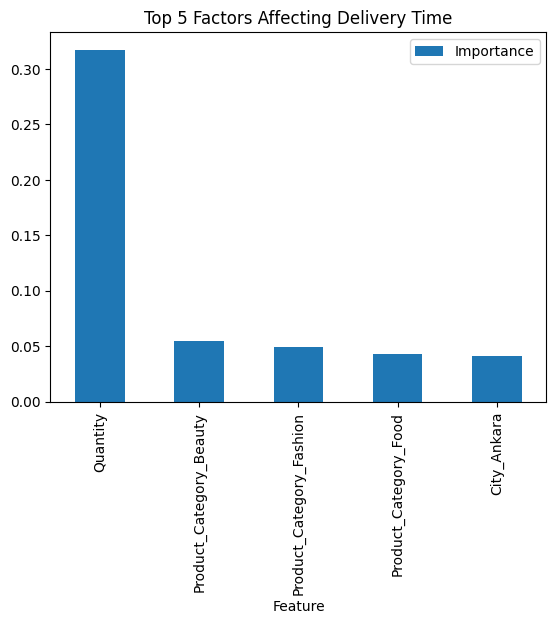

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

#1.Extract feature importances from the trained Random Forest model
importances=rf.feature_importances_
features=X.columns

#2.Create a table to match features with their importance scores
importance_df=pd.DataFrame({'Feature':features,'Importance':importances})

#3.Sort and pick the top 5 most important factors to plot
top_5_features=importance_df.sort_values('Importance',ascending=False).head(5)

#4.Plot the result
top_5_features.plot(x='Feature',y='Importance',kind='bar',title='Top 5 Factors Affecting Delivery Time')
plt.show()

In [7]:
df.to_csv('part3 logistics data.csv',index=False)